In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

### Exercise 6 - Bulirsch-Stoer Method and Planetary Orbits.

1. Repeat Exercise 5, calculating Earth's planetary orbit with the same initial conditions, using the Bulirsch-Stoer method with a per-unit-time error of 1 km/year, dividing the time interval into weekly periods. Show Earth's orbit over at least two complete revolutions around the Sun.

2. Modify the program to calculate Pluto's orbit, whose perihelion is at a distance of $4.4368\times 10^{9}$ km from the Sun and whose speed at that point is 6.1218 km/s. Use the same per-unit-time precision but determine the value of $H$ that allows obtaining a periodic orbit in a reasonable simulation time.


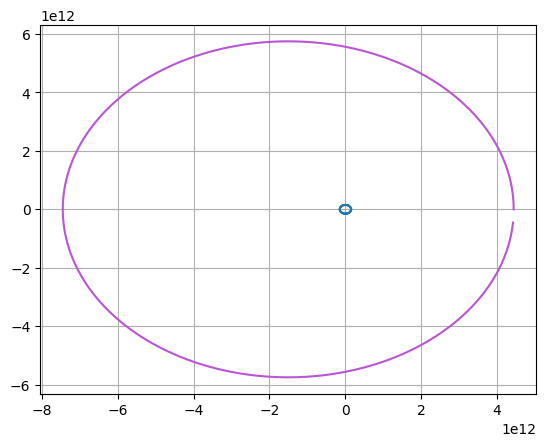

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def bulirsch4(F, a, b, H, r, delta):
    tpp = np.arange(a, b, H)

    xpp = []
    ypp = []
    vxpp = []
    vypp = []

    r = np.array(r, float)

    for t in tpp:
        xpp.append(r[0])
        ypp.append(r[1])
        vxpp.append(r[2])
        vypp.append(r[3])

        n = 1
        r1 = r + 0.5 * H * F(r)
        r2 = r + H * F(r1)

        R1 = np.zeros((n, 4), float)
        R1[0] = 0.5 * (r1 + r2 + 0.5 * H * F(r2))

        error = 2 * H * delta

        while error > H * delta:
            n += 1
            h = H / n

            r1 = r + 0.5 * h * F(r)
            r2 = r + h * F(r1)

            for _ in range(n - 1):
                r1 += h * F(r2)
                r2 += h * F(r1)

            R2 = R1
            R1 = np.zeros((n, 4), float)
            R1[0] = 0.5 * (r1 + r2 + 0.5 * h * F(r2))

            for m in range(1, n):
                eps = (R1[m - 1] - R2[m - 1]) / ((n / (n - 1)) ** (2 * m) - 1)
                R1[m] = R1[m - 1] + eps

            error = abs(eps[0])

        r = R1[n - 1]

    return tpp, xpp, ypp


year = 365.25 * 24 * 3600
week = 7 * 24 * 3600
delta = 1000 / year

a = 0
b = 2 * year
H = week


def F(r):
    G = 6.67e-11
    M = 1.9891e30

    x = r[0]
    y = r[1]
    vx = r[2]
    vy = r[3]

    fx = vx
    fy = vy
    fvx = -G * M * x / (x**2 + y**2) ** 1.5
    fvy = -G * M * y / (x**2 + y**2) ** 1.5

    return np.array([fx, fy, fvx, fvy], float)


r1 = [1.521e11, 0.0, 0.0, 2.9291e4]
rEarth = np.array(r1, float)

t, x, y = bulirsch4(F, a, b, H, rEarth, delta)
plt.plot(x, y)

a2 = 0
b2 = 248 * year

r2 = [4.4368e12, 0.0, 0.0, 6.1218e3]
rPluto = np.array(r2, float)

t2, x2, y2 = bulirsch4(F, a2, b2, H, rPluto, delta)

plt.plot(x2, y2, color = mc)
plt.grid()
plt.show()
